## Overfitting Analysis and Regularization Techniques

This notebook aims to study the effect of Dropout, L2 Regularization, and Batch Normalization on overfitting in deep neural networks using the MNIST dataset.

### Step 1: Train a baseline MLP on MNIST

First, we'll import the necessary libraries, load and preprocess the MNIST dataset, and define a simple Multi-Layer Perceptron (MLP) model. We'll then train this model and record its performance.

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [16]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
y_train shape: (60000,)
x_test shape: (10000, 784)
y_test shape: (10000,)


In [17]:
# Define the baseline MLP model
def build_baseline_mlp():
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    return model

baseline_model = build_baseline_mlp()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile and train the baseline model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20, # Using more epochs to observe overfitting clearly
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9084 - loss: 0.3168 - val_accuracy: 0.9599 - val_loss: 0.1415
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9647 - loss: 0.1173 - val_accuracy: 0.9678 - val_loss: 0.1078
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9769 - loss: 0.0775 - val_accuracy: 0.9696 - val_loss: 0.1028
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9734 - val_loss: 0.0853
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9870 - loss: 0.0410 - val_accuracy: 0.9748 - val_loss: 0.0866
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9739 - val_loss: 0.0936
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9772 - val_loss: 0.0836
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accura

### Step 2: Observe training vs validation loss and accuracy

We will now plot the training and validation loss and accuracy to visualize the model's performance and identify any signs of overfitting.

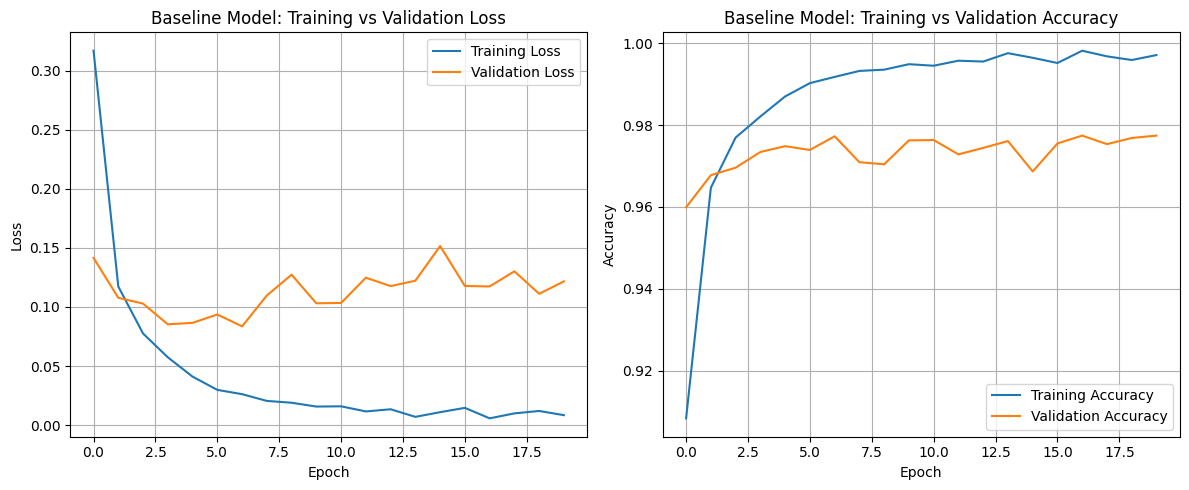

In [19]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Evaluate the baseline model on the test set
loss_baseline, accuracy_baseline = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline Model Test Loss: {loss_baseline:.4f}")
print(f"Baseline Model Test Accuracy: {accuracy_baseline:.4f}")

Baseline Model Test Loss: 0.1111
Baseline Model Test Accuracy: 0.9777


### Step 6: Compare performance

Now we will compare the training and validation loss and accuracy across all the models (baseline, Dropout, L2 Regularization, and Batch Normalization) to analyze their effectiveness in mitigating overfitting.

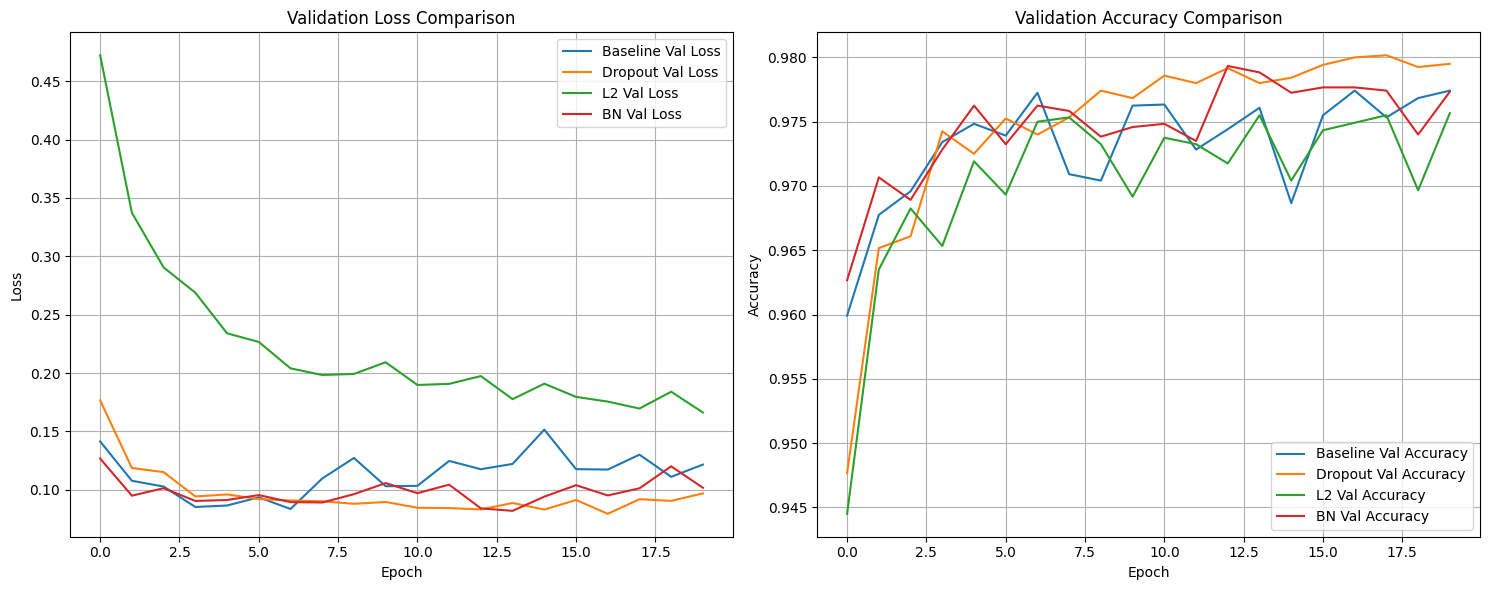

In [38]:
import matplotlib.pyplot as plt

# Plot comparison of Validation Loss
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_loss'], label='Baseline Val Loss')
plt.plot(history_dropout.history['val_loss'], label='Dropout Val Loss')
plt.plot(history_l2.history['val_loss'], label='L2 Val Loss')
plt.plot(history_bn.history['val_loss'], label='BN Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot comparison of Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout Val Accuracy')
plt.plot(history_l2.history['val_accuracy'], label='L2 Val Accuracy')
plt.plot(history_bn.history['val_accuracy'], label='BN Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Summarize test set performance
print(f"\n--- Test Set Performance ---")
print(f"Baseline Model   - Loss: {loss_baseline:.4f}, Accuracy: {accuracy_baseline:.4f}")
print(f"Dropout Model    - Loss: {loss_dropout:.4f}, Accuracy: {accuracy_dropout:.4f}")
print(f"L2 Regularized Model - Loss: {loss_l2:.4f}, Accuracy: {accuracy_l2:.4f}")
print(f"Batch Normalization Model - Loss: {loss_bn:.4f}, Accuracy: {accuracy_bn:.4f}")


--- Test Set Performance ---
Baseline Model   - Loss: 0.1111, Accuracy: 0.9777
Dropout Model    - Loss: 0.0834, Accuracy: 0.9805
L2 Regularized Model - Loss: 0.1626, Accuracy: 0.9766
Batch Normalization Model - Loss: 0.0857, Accuracy: 0.9784


### Step 5: Apply Batch Normalization

Finally, we'll implement Batch Normalization layers. Batch Normalization helps to stabilize and accelerate the training process of deep neural networks by normalizing the inputs of each layer, reducing the internal covariate shift.

In [26]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the MLP model with Batch Normalization
def build_bn_mlp():
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(10, activation="softmax"),
    ])
    return model

bn_model = build_bn_mlp()
bn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [35]:
from tensorflow import keras

# Compile and train the Batch Normalization model
bn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_bn = bn_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9303 - loss: 0.2415 - val_accuracy: 0.9627 - val_loss: 0.1268
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9733 - loss: 0.0898 - val_accuracy: 0.9707 - val_loss: 0.0950
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9814 - loss: 0.0592 - val_accuracy: 0.9689 - val_loss: 0.1014
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9858 - loss: 0.0447 - val_accuracy: 0.9728 - val_loss: 0.0905
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9897 - loss: 0.0332 - val_accuracy: 0.9762 - val_loss: 0.0913
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9906 - loss: 0.0279 - val_accuracy: 0.9732 - val_loss: 0.0955
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9762 - val_loss: 0.0895
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9926 - loss: 0.0215 - val_accu

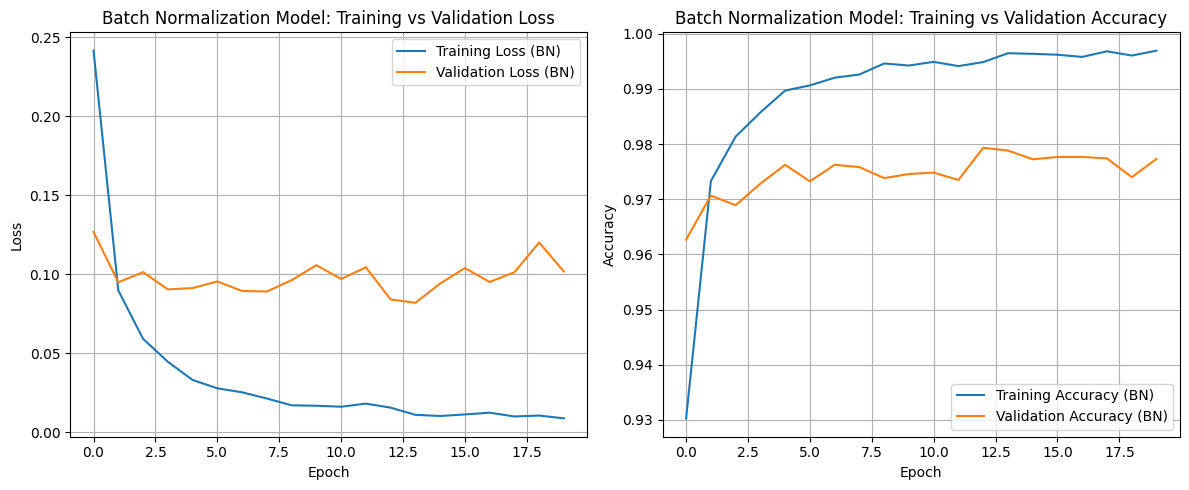

In [39]:
import matplotlib.pyplot as plt

# Plot training and validation loss for Batch Normalization model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_bn.history['loss'], label='Training Loss (BN)')
plt.plot(history_bn.history['val_loss'], label='Validation Loss (BN)')
plt.title('Batch Normalization Model: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for Batch Normalization model
plt.subplot(1, 2, 2)
plt.plot(history_bn.history['accuracy'], label='Training Accuracy (BN)')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy (BN)')
plt.title('Batch Normalization Model: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
# Evaluate the Batch Normalization model on the test set
loss_bn, accuracy_bn = bn_model.evaluate(x_test, y_test, verbose=0)
print(f"Batch Normalization Model Test Loss: {loss_bn:.4f}")
print(f"Batch Normalization Model Test Accuracy: {accuracy_bn:.4f}")

Batch Normalization Model Test Loss: 0.0857
Batch Normalization Model Test Accuracy: 0.9784


### Step 4: Apply L2 Regularization

Next, we'll add L2 regularization to the MLP model. L2 regularization (also known as weight decay) penalizes large weights, encouraging the model to use smaller weights and reducing model complexity, thus helping to prevent overfitting.

In [24]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Define the MLP model with L2 regularization
def build_l2_mlp(l2_lambda=0.001):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(10, activation="softmax"),
    ])
    return model

l2_model = build_l2_mlp()
l2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow import keras

# Compile and train the L2 regularized model
l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_l2 = l2_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9096 - loss: 0.6875 - val_accuracy: 0.9445 - val_loss: 0.4722
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9589 - loss: 0.3886 - val_accuracy: 0.9635 - val_loss: 0.3373
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9678 - loss: 0.3038 - val_accuracy: 0.9682 - val_loss: 0.2905
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9726 - loss: 0.2575 - val_accuracy: 0.9653 - val_loss: 0.2688
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9746 - loss: 0.2323 - val_accuracy: 0.9719 - val_loss: 0.2341
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9763 - loss: 0.2128 - val_accuracy: 0.9693 - val_loss: 0.2267
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9780 - loss: 0.1978 - val_accuracy: 0.9750 - val_loss: 0.2041
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9779 - loss: 0.1889 - val_accu

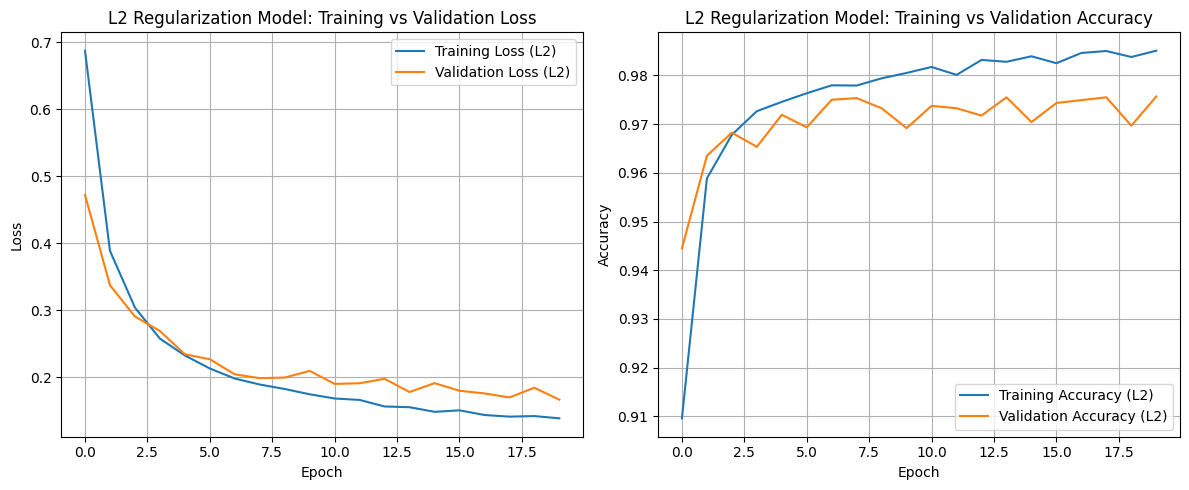

In [40]:
import matplotlib.pyplot as plt

# Plot training and validation loss for L2 model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_l2.history['loss'], label='Training Loss (L2)')
plt.plot(history_l2.history['val_loss'], label='Validation Loss (L2)')
plt.title('L2 Regularization Model: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for L2 model
plt.subplot(1, 2, 2)
plt.plot(history_l2.history['accuracy'], label='Training Accuracy (L2)')
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy (L2)')
plt.title('L2 Regularization Model: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
# Evaluate the L2 regularized model on the test set
loss_l2, accuracy_l2 = l2_model.evaluate(x_test, y_test, verbose=0)
print(f"L2 Regularized Model Test Loss: {loss_l2:.4f}")
print(f"L2 Regularized Model Test Accuracy: {accuracy_l2:.4f}")

L2 Regularized Model Test Loss: 0.1626
L2 Regularized Model Test Accuracy: 0.9766


### Step 3: Apply Dropout

Now, we'll introduce Dropout layers into our MLP model to mitigate overfitting. Dropout randomly sets a fraction of input units to 0 at each update during training, which helps prevent complex co-adaptations on training data.

In [22]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the MLP model with Dropout
def build_dropout_mlp(dropout_rate=0.3):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax"),
    ])
    return model

dropout_model = build_dropout_mlp()
dropout_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow import keras

# Compile and train the Dropout model
dropout_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8276 - loss: 0.5629 - val_accuracy: 0.9477 - val_loss: 0.1766
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9380 - loss: 0.2174 - val_accuracy: 0.9652 - val_loss: 0.1187
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9549 - loss: 0.1616 - val_accuracy: 0.9661 - val_loss: 0.1152
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9608 - loss: 0.1375 - val_accuracy: 0.9743 - val_loss: 0.0943
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9666 - loss: 0.1157 - val_accuracy: 0.9725 - val_loss: 0.0961
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9707 - loss: 0.1027 - val_accuracy: 0.9753 - val_loss: 0.0921
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9733 - loss: 0.0917 - val_accuracy: 0.9740 - val_loss: 0.0909
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9754 - loss: 0.0852 - val_accu

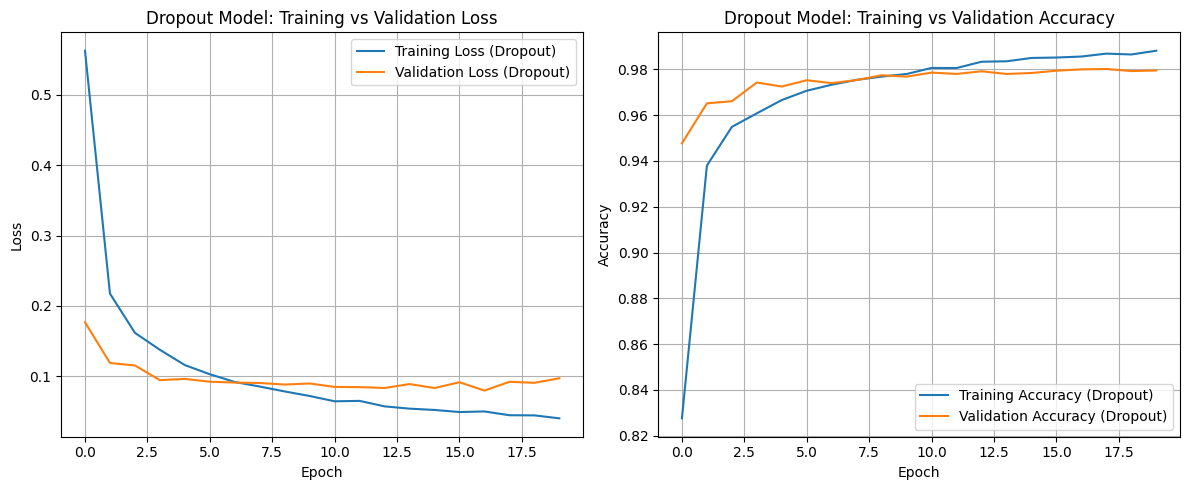

In [41]:
import matplotlib.pyplot as plt

# Plot training and validation loss for Dropout model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Training Loss (Dropout)')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss (Dropout)')
plt.title('Dropout Model: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy for Dropout model
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], label='Training Accuracy (Dropout)')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy (Dropout)')
plt.title('Dropout Model: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

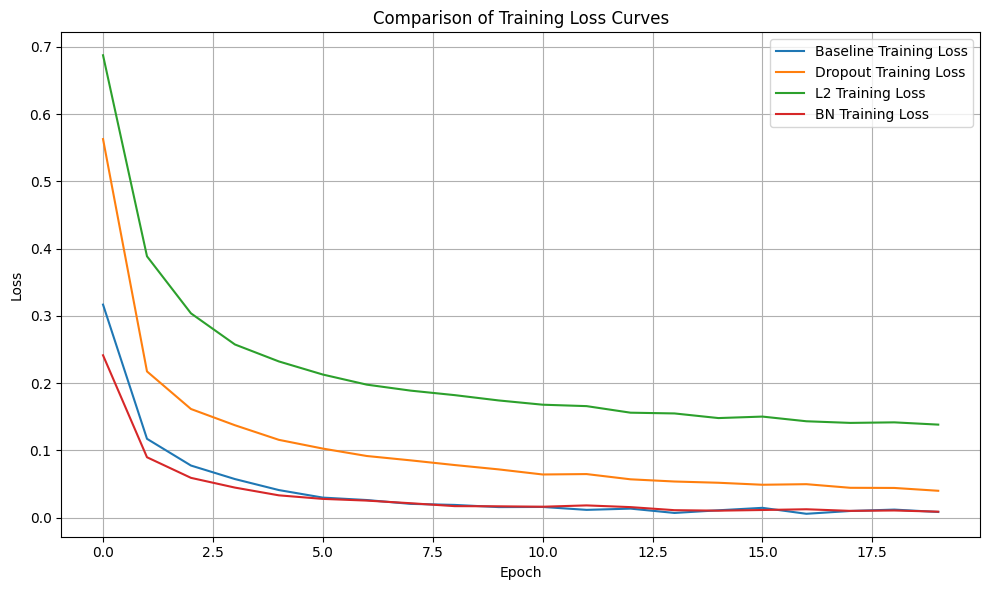

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['loss'], label='Baseline Training Loss')
plt.plot(history_dropout.history['loss'], label='Dropout Training Loss')
plt.plot(history_l2.history['loss'], label='L2 Training Loss')
plt.plot(history_bn.history['loss'], label='BN Training Loss')
plt.title('Comparison of Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Evaluate the Dropout model on the test set
loss_dropout, accuracy_dropout = dropout_model.evaluate(x_test, y_test, verbose=0)
print(f"Dropout Model Test Loss: {loss_dropout:.4f}")
print(f"Dropout Model Test Accuracy: {accuracy_dropout:.4f}")

Dropout Model Test Loss: 0.0834
Dropout Model Test Accuracy: 0.9805
